In [9]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
import joblib
from pathlib import Path
from tqdm.notebook import tqdm
import pystac
from scipy.ndimage import uniform_filter
import rasterio
from skimage.filters import threshold_otsu
from itertools import combinations
import pickle

from helpers.shared import assert_grid_match, normalised_diff, time_match

In [10]:
from config import *

# -- Catalog --------------------------------------------------------------------------------------------
CATALOG         = load_catalog()
INPUT_ASSET     = {
                    "imagery": "norm",
                    "seagrass": "ard"
                }
# -- Bands ----------------------------------------------------------------------------------------------
NORM_BAND_NAMES = {
    "wv2-imagery": ["B", "G", "Y", "R"],
    "sd8-imagery": ["B", "G", "Y", "R"],
}

SENSOR_BIN = {"wv2-imagery": 0, "sd8-imagery": 1}

# -- Algorithm Parameters -------------------------------------------------------------------------------
# MAX_FILLED_BANDS = 3
# WINDOWS = [3, 7, 15]
LOG_EPS = 1e-6
STD_THRESH = 75 # std thresh at 90th percentile = mask out pixels with top 25% largest pred int (i.e the most inaccurate)
PX_BUFF = 100 # buffer around bathy input 
PRED_BATCH = 500_000 # px batch size for predicting

# -- Output Options -------------------------------------------------------------------------------------
OUT_DIR                 = Path("../out/pred/")
MKDIR                   = True
OUT_NAMES                = {
                            "stack": "stack1",
                            "pred": "bathy-pred1",
                            "std": "std1",
                        }
OUT_EXT                 = "tif"

# -- Execution Flags ------------------------------------------------------------------------------------
OVERWRITE               = True

In [11]:
OUT_DIR.mkdir(exist_ok=MKDIR)

In [12]:
img_items = [
    item for col_id in ["wv2-imagery", "sd8-imagery"]
    for item in CATALOG.get_child(col_id).get_items()
]

bathy_col = CATALOG.get_child("bathymetry")

sg_percov_items = list(CATALOG.get_child("seagrass-percov").get_items())
sg_species_items = list(CATALOG.get_child("seagrass-species").get_items())

all_items = img_items + sg_percov_items + sg_species_items

In [13]:
matches = [
    dict(
    img = img,
    percov = time_match(sg_percov_items, img.datetime),
    species = time_match(sg_species_items, img.datetime)
    ) for img in img_items
]

In [14]:
with open("../out/rf/model-XGBRegressor-final.pkl", "rb") as f:
    saved = pickle.load(f)

m = saved["model"]
m_low = saved["lower"]
m_high = saved["upper"]
features = saved["features"]
params = saved["params"]

In [15]:
import importlib.util
from types import ModuleType
from pathlib import Path

sys.modules.setdefault('acolite', ModuleType('acolite'))

spec = importlib.util.spec_from_file_location(
    "p3qaa_compute",
    "../acolite/acolite/parameters/pitarch/p3qaa_compute.py"
)
_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_mod)
p3qaa_compute = _mod.p3qaa_compute

P3QAA_SENSOR = {'wv2': 'WorldView2', 'sd8': 'PlanetScope_SD8'}
P3QAA_DIR = Path("../acolite/data/Shared/algorithms/P3QAA")

PARS = ['alpha','aw','bbw','beta1','beta2','bg_ratio','center_wl','chi','coef_z_sd']
p3qaa_cfg = {}
for par in PARS:
    with open(P3QAA_DIR / f"{par}.csv") as f:
        header = None
        for line in f:
            line = line.strip()
            if not line or line[0] in ['#', ';']: continue
            sp = line.split(',')
            if header is None: header = sp; continue
            sensor = sp[0]
            p3qaa_cfg.setdefault(sensor, {})[par] = d = {h: sp[i] for i,h in enumerate(header)}
            for k in ['p4','p3','p2','p1','p0','R','G','B']:
                if k in d: d[k] = float(d[k])

In [16]:
from scipy.ndimage import binary_dilation

bathy_mask = rxr.open_rasterio(bathy_col.assets["bathy-coverage"].href, masked=True).squeeze("band", drop=True).values.astype(bool)
bathy_mask_search = binary_dilation(bathy_mask, iterations = PX_BUFF)

for match in tqdm(matches, desc="predicting"):
    img = match["img"]
    percov = match["percov"]
    species = match["species"]
    img_col = img.collection_id
    band_names = NORM_BAND_NAMES[img_col]

    out_path = OUT_DIR / f"{OUT_NAMES['pred']}-{img.id}.{OUT_EXT}"
    std_path = OUT_DIR / f"{OUT_NAMES['std']}-{img.id}.{OUT_EXT}"

    if out_path.exists() and std_path.exists() and not OVERWRITE:
        tqdm.write(f"Skipping: {img.id}")
        continue

    with rasterio.open(img.assets["norm"].href) as src:
        profile = src.profile.copy()
        H, W = src.height, src.width
        i_data = src.read()

    p_data = rxr.open_rasterio(percov.assets["ard"].href, masked=True).squeeze("band", drop=True).values
    s_data = rxr.open_rasterio(species.assets["ard"].href, masked=True).squeeze("band", drop=True).values

    valid = np.isfinite(i_data).all(axis=0) & np.isfinite(p_data) & np.isfinite(s_data) & bathy_mask_search
    idx = np.where(valid.ravel())[0]
    del valid

    N = len(idx)

    i_flat = i_data.reshape(i_data.shape[0], -1)[:, idx].T
    del i_data

    df = pd.DataFrame(i_flat, columns=band_names)
    del i_flat

    df["sg_percov"] = p_data.ravel()[idx]
    df["sg_species"] = s_data.ravel()[idx]
    del p_data, s_data

    df["sensor"] = SENSOR_BIN[img_col]
    df["tide_h"] = img.extra_fields["tide_height_m"]

    B, G, R = df["B"].values.astype(float), df["G"].values.astype(float), df["R"].values.astype(float)
    water = np.all((np.stack([B, G, R]) > 0) & np.isfinite(np.stack([B, G, R])), axis=0)

    for col in ['a_B', 'a_G', 'a_R', 'Kd_G', 'zSD']:
        df[col] = np.nan
    if water.sum() > 0:
        res = p3qaa_compute(P3QAA_SENSOR[img_col[:3]], B[water], G[water], R[water], cfg=p3qaa_cfg)
        a, Kd, zSD = res['a'].squeeze(), res['Kd'].squeeze(), res['zSD'].squeeze()
        df.loc[water, 'a_B']  = a[:, 0]
        df.loc[water, 'a_G']  = a[:, 1]
        df.loc[water, 'a_R']  = a[:, 2]
        df.loc[water, 'Kd_G'] = np.clip(Kd[:, 1], 0, 20)
        df.loc[water, 'zSD']  = np.clip(zSD, 0, None)
        del a, Kd, zSD, res
    del B, G, R, water

    for b in band_names:
        df[f"log_{b}"] = np.log(df[b].where(df[b] > 0))
    for b1, b2 in combinations(band_names, 2):
        denom = (df[b1] + df[b2]).where((df[b1] + df[b2]) != 0)
        df[f"nd_{b1}_{b2}"] = (df[b1] - df[b2]) / denom

    X = np.clip(df[features].values, np.finfo(np.float32).min, np.finfo(np.float32).max).astype(np.float32)
    del df

    pred_flat = np.full(H * W, np.nan, dtype=np.float32)
    std_flat = np.full(H * W, np.nan, dtype=np.float32)

    for start in tqdm(range(0, N, PRED_BATCH), desc=img.id, leave=False):
        end = min(start + PRED_BATCH, N)
        X_b = X[start:end]
        ok = np.isfinite(X_b).all(axis=1)
        if ok.sum() > 0:
            pred_flat[idx[start:end][ok]] = m.predict(X_b[ok])
            std_flat[idx[start:end][ok]] = m_high.predict(X_b[ok]) - m_low.predict(X_b[ok])

    del X

    # --- post-hoc filter ---
    # 1. bathy_mask becomes a GATE for calculating a std threshold, i.e its gonna remove most open ocean from the std thresh calc, but its not gonna actually be used to mask out the preds
    within_mask = bathy_mask.ravel()[idx]
    std_thresh = np.nanpercentile(std_flat[idx[within_mask]], STD_THRESH)
    keep = (std_flat < std_thresh) & (pred_flat >= -3.0) & (pred_flat < 0)
    pred_flat[~keep] = np.nan
    std_flat[~keep] = np.nan

    out_profile = profile.copy()
    out_profile.update(count=1, dtype="float32", nodata=np.nan, compress="lzw")

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(pred_flat.reshape(H, W), 1)

    with rasterio.open(std_path, "w", **out_profile) as dst:
        dst.write(std_flat.reshape(H, W), 1)
        
    tqdm.write(f"Saved: {img.id}")

predicting:   0%|          | 0/8 [00:00<?, ?it/s]

wv2-20110610:   0%|          | 0/40 [00:00<?, ?it/s]

Saved: wv2-20110610


wv2-20120620:   0%|          | 0/38 [00:00<?, ?it/s]

Saved: wv2-20120620


...

Saved: sd8-20230706


sd8-20240722:   0%|          | 0/40 [00:00<?, ?it/s]

Saved: sd8-20240722


sd8-20250610:   0%|          | 0/40 [00:00<?, ?it/s]

Saved: sd8-20250610


In [17]:
# bathy_mask = rxr.open_rasterio(bathy_col.assets["bathy-coverage"].href, masked=True).squeeze("band", drop=True).values.astype(bool)

# for match in tqdm(matches, desc="predicting"):
#     img     = match["img"]
#     percov  = match["percov"]
#     species = match["species"]
#     img_col    = img.collection_id
#     band_names = NORM_BAND_NAMES[img_col]

#     out_path = OUT_DIR / f"{OUT_NAMES['pred']}-{img.id}.{OUT_EXT}"
#     std_path = OUT_DIR / f"{OUT_NAMES['std']}-{img.id}.{OUT_EXT}"

#     if out_path.exists() and std_path.exists() and not OVERWRITE:
#         tqdm.write(f"Skipping: {img.id}")
#         continue

#     with rasterio.open(img.assets["norm"].href) as src:
#         profile = src.profile.copy()
#         H, W    = src.height, src.width
#         i_data  = src.read()

#     p_data = rxr.open_rasterio(percov.assets["ard"].href, masked=True).squeeze("band", drop=True).values
#     s_data = rxr.open_rasterio(species.assets["ard"].href, masked=True).squeeze("band", drop=True).values

#     valid = np.isfinite(i_data).all(axis=0) & np.isfinite(p_data) & np.isfinite(s_data) & bathy_mask
#     idx   = np.where(valid.ravel())[0]
#     N     = len(idx)

#     i_flat = i_data.reshape(i_data.shape[0], -1)[:, idx].T
#     df     = pd.DataFrame(i_flat, columns=band_names)
#     df["sg_percov"]  = p_data.ravel()[idx]
#     df["sg_species"] = s_data.ravel()[idx]
#     df["sensor"]     = SENSOR_BIN[img_col]
#     df["tide_h"]     = img.extra_fields["tide_height_m"]

#     B, G, R = df["B"].values.astype(float), df["G"].values.astype(float), df["R"].values.astype(float)
#     water   = np.all((np.stack([B, G, R]) > 0) & np.isfinite(np.stack([B, G, R])), axis=0)

#     for col in ['a_B', 'a_G', 'a_R', 'Kd_G', 'zSD']:
#         df[col] = np.nan
#     if water.sum() > 0:
#         res = p3qaa_compute(P3QAA_SENSOR[img_col[:3]], B[water], G[water], R[water], cfg=p3qaa_cfg)
#         a, Kd, zSD = res['a'].squeeze(), res['Kd'].squeeze(), res['zSD'].squeeze()
#         df.loc[water, 'a_B']  = a[:, 0]
#         df.loc[water, 'a_G']  = a[:, 1]
#         df.loc[water, 'a_R']  = a[:, 2]
#         df.loc[water, 'Kd_G'] = np.clip(Kd[:, 1], 0, 20)
#         df.loc[water, 'zSD']  = np.clip(zSD, 0, None)

#     for b in band_names:
#         df[f"log_{b}"] = np.log(df[b].where(df[b] > 0))
#     for b1, b2 in combinations(band_names, 2):
#         denom = (df[b1] + df[b2]).where((df[b1] + df[b2]) != 0)
#         df[f"nd_{b1}_{b2}"] = (df[b1] - df[b2]) / denom

#     X = np.clip(df[features].values, np.finfo(np.float32).min, np.finfo(np.float32).max).astype(np.float32)
#     pred_flat = np.full(H * W, np.nan, dtype=np.float32)
#     std_flat  = np.full(H * W, np.nan, dtype=np.float32)

#     for start in tqdm(range(0, N, PRED_BATCH), desc=img.id, leave=False):
#         end = min(start + PRED_BATCH, N)
#         X_b = X[start:end]
#         ok  = np.isfinite(X_b).all(axis=1)
#         if ok.sum() > 0:
#             pred_flat[idx[start:end][ok]] = m.predict(X_b[ok])
#             std_flat[idx[start:end][ok]]  = m_high.predict(X_b[ok]) - m_low.predict(X_b[ok])

#     out_profile = profile.copy()
#     out_profile.update(count=1, dtype="float32", nodata=np.nan, compress="lzw")

#     with rasterio.open(out_path, "w", **out_profile) as dst:
#         dst.write(pred_flat.reshape(H, W), 1)

#     with rasterio.open(std_path, "w", **out_profile) as dst:
#         dst.write(std_flat.reshape(H, W), 1)
        
#     tqdm.write(f"Saved: {img.id}")


In [20]:
for match in tqdm(matches, desc="stacking"):
    img = match["img"]
    percov = match["percov"]
    species = match["species"]
    img_col = img.collection_id
    band_names = NORM_BAND_NAMES[img_col]

    out_path = OUT_DIR / f"{OUT_NAMES['pred']}-{img.id}.{OUT_EXT}"
    std_path = OUT_DIR / f"{OUT_NAMES['std']}-{img.id}.{OUT_EXT}"
    stack_path = OUT_DIR / f"{OUT_NAMES['stack']}-{img.id}.parquet"

    if stack_path.exists() and not OVERWRITE:
        tqdm.write(f"Skipping: {img.id}")
        continue

    with rasterio.open(img.assets["norm"].href) as src:
        H, W = src.height, src.width
        i_data = src.read()

    p_data = rxr.open_rasterio(percov.assets["ard"].href, masked=True).squeeze("band", drop=True).values
    s_data = rxr.open_rasterio(species.assets["ard"].href, masked=True).squeeze("band", drop=True).values

    valid = np.isfinite(i_data).all(axis=0) & np.isfinite(p_data) & np.isfinite(s_data) & bathy_mask
    idx = np.where(valid.ravel())[0]

    i_flat = i_data.reshape(i_data.shape[0], -1)[:, idx].T
    df = pd.DataFrame(i_flat, columns=band_names)
    df["sg_percov"] = p_data.ravel()[idx]
    df["sg_species"] = s_data.ravel()[idx]
    df["sensor"] = SENSOR_BIN[img_col]
    df["tide_h"] = img.extra_fields["tide_height_m"]

    B, G, R = df["B"].values.astype(float), df["G"].values.astype(float), df["R"].values.astype(float)
    water = np.all((np.stack([B, G, R]) > 0) & np.isfinite(np.stack([B, G, R])), axis=0)

    for col in ['a_B', 'a_G', 'a_R', 'Kd_G', 'zSD']:
        df[col] = np.nan
    if water.sum() > 0:
        res = p3qaa_compute(P3QAA_SENSOR[img_col[:3]], B[water], G[water], R[water], cfg=p3qaa_cfg)
        a, Kd, zSD = res['a'].squeeze(), res['Kd'].squeeze(), res['zSD'].squeeze()
        df.loc[water, 'a_B'] = a[:, 0]
        df.loc[water, 'a_G'] = a[:, 1]
        df.loc[water, 'a_R'] = a[:, 2]
        df.loc[water, 'Kd_G'] = np.clip(Kd[:, 1], 0, 20)
        df.loc[water, 'zSD'] = np.clip(zSD, 0, None)

    for b in band_names:
        df[f"log_{b}"] = np.log(df[b].where(df[b] > 0))
    for b1, b2 in combinations(band_names, 2):
        denom = (df[b1] + df[b2]).where((df[b1] + df[b2]) != 0)
        df[f"nd_{b1}_{b2}"] = (df[b1] - df[b2]) / denom

    with rasterio.open(out_path) as src:
        pred_flat = src.read(1).ravel().astype(np.float32)
        
    with rasterio.open(std_path) as src:
        std_flat = src.read(1).ravel().astype(np.float32)

    df["idx"] = idx
    df["pred"] = pred_flat[idx]
    df["std"] = std_flat[idx]
    df["img_id"] = img.id
    df["date"] = img.datetime
    df.to_parquet(stack_path, index=False)
    tqdm.write(f"Saved: {stack_path.name}")


stacking:   0%|          | 0/8 [00:00<?, ?it/s]

Saved: stack1-wv2-20110610.parquet
Saved: stack1-wv2-20120620.parquet
Saved: stack1-wv2-20140714.parquet


c:\Users\samla\study\25-SEM3.ENVM7133\ENVM7133\notebooks\../acolite/acolite/parameters/pitarch/p3qaa_compute.py:76: RuntimeWarning: invalid value encountered in sqrt
  u=((-g0+(g0**2+4*g1*rrs)**0.5)/(2*g1))
c:\Users\samla\study\25-SEM3.ENVM7133\ENVM7133\notebooks\../acolite/acolite/parameters/pitarch/p3qaa_compute.py:78: RuntimeWarning: overflow encountered in exp
  eta=2*(1-1.2*np.exp(-0.9*pscaled(B/G)))
c:\Users\samla\study\25-SEM3.ENVM7133\ENVM7133\notebooks\../acolite/acolite/parameters/pitarch/p3qaa_compute.py:81: RuntimeWarning: overflow encountered in power
  bbp[:,:,bi] = bbpl0[:,:]*(l0/wave[bi])**eta[:,:]
c:\Users\samla\study\25-SEM3.ENVM7133\ENVM7133\notebooks\../acolite/acolite/parameters/pitarch/p3qaa_compute.py:94: RuntimeWarning: invalid value encountered in add
  Kd=a+(1-gamma*bbw_frac)*m1*(1-m2*np.exp(-m3*a))*bb #Spectral diffuse attenuation coefficient


Saved: stack1-wv2-20150701.parquet
Saved: stack1-sd8-20220713.parquet
Saved: stack1-sd8-20230706.parquet
Saved: stack1-sd8-20240722.parquet
Saved: stack1-sd8-20250610.parquet


In [21]:
registered = []
for match in matches:
    img = match["img"]
    out_path = OUT_DIR / f"{OUT_NAMES['pred']}-{img.id}.{OUT_EXT}"
    std_path = OUT_DIR / f"{OUT_NAMES['std']}-{img.id}.{OUT_EXT}"
    stack_path = OUT_DIR / f"{OUT_NAMES['stack']}-{img.id}.parquet"
    
    pred_asset = pystac.Asset(
        href = str(out_path.resolve()),
        media_type = pystac.MediaType.GEOTIFF,
        title = OUT_NAMES["pred"],
        roles = ["data"],
        description = "Satellite-derived bathymetry prediction (m LAT)"
    )

    std_asset = pystac.Asset(
        href=str(std_path.resolve()),
        media_type=pystac.MediaType.GEOTIFF,
        title="SDB Uncertainty",
        roles=["data"],
        description="Prediction interval width (m): upper quantile - lower quantile",
    )

    stack_asset = pystac.Asset(
        href = str(stack_path.resolve()),
        media_type = "application/x-parquet",
        title = "Feature stack",
        roles = ["data"],
        description = "Per-pixel feature table with pred and std (parquet)"
    )

    img.add_asset(
        f"{OUT_NAMES['pred']}", pred_asset
    )

    img.add_asset(
        f"{OUT_NAMES['std']}", std_asset
    )

    img.add_asset(
        f"{OUT_NAMES['stack']}", stack_asset
    )

    tqdm.write(f"Catalog updated: {img.id}")

CATALOG.normalize_hrefs(str(STAC_DIR))
CATALOG.save(catalog_type=pystac.CatalogType.SELF_CONTAINED)
tqdm.write(f"Complete")

Catalog updated: wv2-20110610
Catalog updated: wv2-20120620
Catalog updated: wv2-20140714
Catalog updated: wv2-20150701
Catalog updated: sd8-20220713
Catalog updated: sd8-20230706
Catalog updated: sd8-20240722
Catalog updated: sd8-20250610
Complete


C:\Users\samla\AppData\Local\Temp\ipykernel_3840\3864378147.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


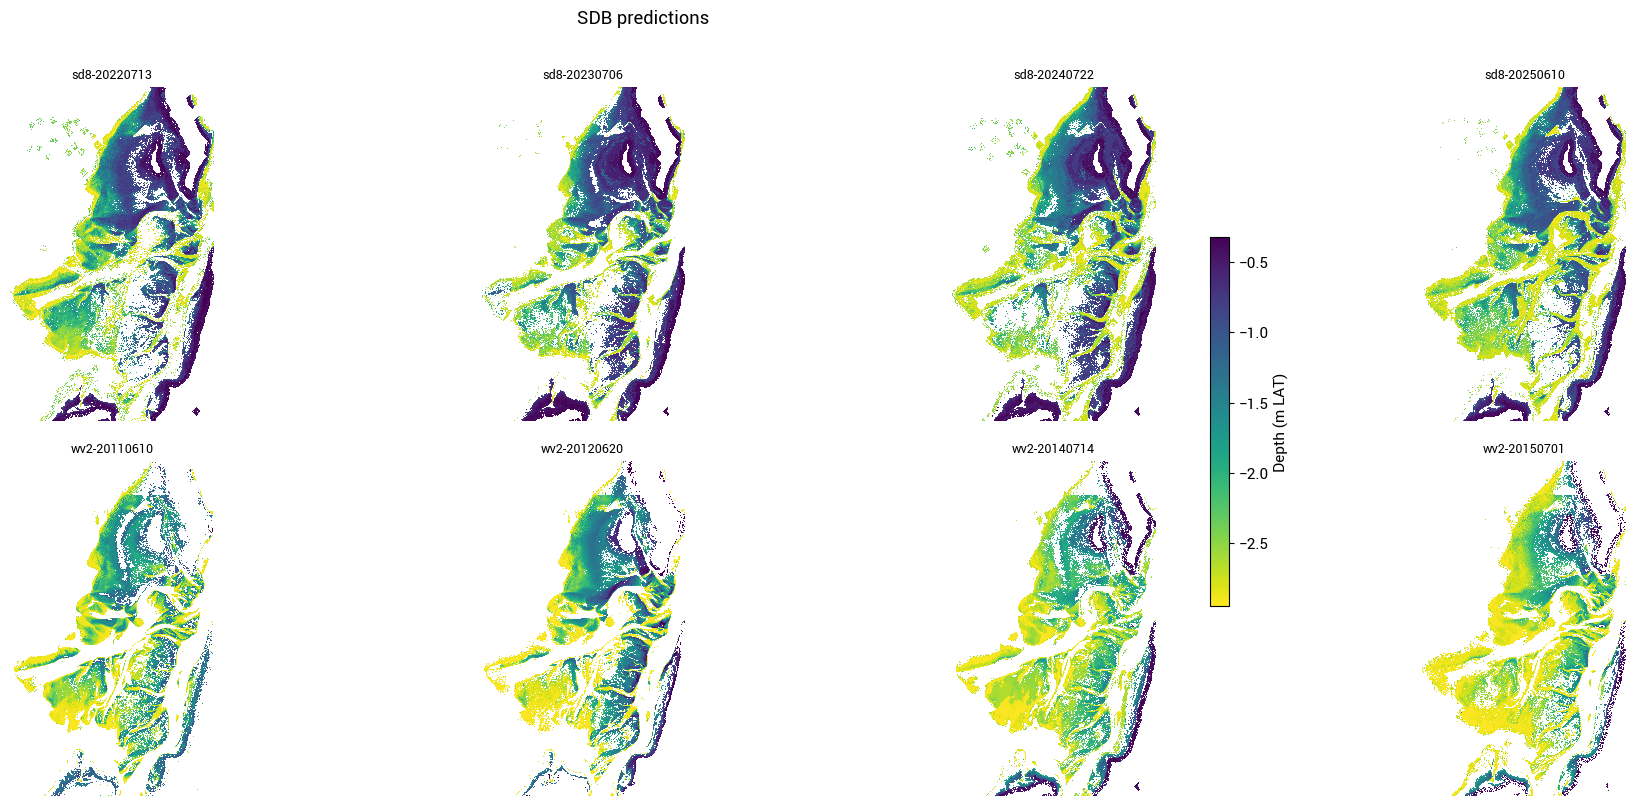

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pred_files = sorted(OUT_DIR.glob(f"{OUT_NAMES['pred']}-*.{OUT_EXT}"))

# --- Common scale across all rasters ---
vmin, vmax = np.inf, -np.inf
arrays = []
titles = []
for f in pred_files:
    with rasterio.open(f) as src:
        arr = src.read(1).astype(float)
        arr[arr == src.nodata] = np.nan
    arrays.append(arr)
    titles.append(f.stem.replace(OUT_NAMES['pred'] + "-", ""))
    vmin = min(vmin, np.nanpercentile(arr, 2))
    vmax = max(vmax, np.nanpercentile(arr, 98))

# --- Plot ---
ncols = 4
nrows = int(np.ceil(len(arrays) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, arr, title in zip(axes, arrays, titles):
    im = ax.imshow(arr, cmap="viridis_r", vmin=vmin, vmax=vmax, interpolation="none")
    ax.set_title(title, fontsize=9)
    ax.axis("off")

for ax in axes[len(arrays):]:
    ax.set_visible(False)

fig.colorbar(im, ax=axes[:len(arrays)], label="Depth (m LAT)", shrink=0.6, pad=0.02)
plt.suptitle("SDB predictions", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
from skimage.morphology import disk, binary_opening, binary_dilation
from rasterio.fill import fillnodata

OPEN_RADIUS  = 2 # removes protrusions and isolated px smaller than this
DILATE_EXTRA = 1 # recover any over-erosion at real edges

for pred_f in tqdm(pred_files, desc="post-processing"):
    std_f = OUT_DIR / pred_f.name.replace(OUT_NAMES["pred"], OUT_NAMES["std"])

    with rasterio.open(pred_f) as src:
        pred_arr = src.read(1)
        profile  = src.profile.copy()
        nodata   = src.nodata

    with rasterio.open(std_f) as src:
        std_arr = src.read(1)

    valid = np.isfinite(pred_arr) & (pred_arr != nodata)
    clean_mask = binary_dilation(binary_opening(valid, disk(OPEN_RADIUS)), disk(DILATE_EXTRA))

    pred_filled = fillnodata(pred_arr, mask=clean_mask.astype(np.uint8), max_search_distance=10)
    std_filled = fillnodata(std_arr,  mask=clean_mask.astype(np.uint8), max_search_distance=10)

    for f, arr in [(pred_f, pred_filled), (std_f, std_filled)]:
        with rasterio.open(f, "w", **profile) as dst:
            dst.write(np.where(clean_mask, arr, nodata).astype(np.float32), 1)
        with rasterio.open(f, "r+") as dst:
            dst.build_overviews([2, 4, 8, 16, 32], rasterio.enums.Resampling.average)
            dst.update_tags(ns="rio_overview", resampling="average")

    tqdm.write(f"Done: {pred_f.name}")
